In [3]:
from faker import Faker
import pandas as pd
import numpy as np
import random

fake = Faker()

num_records = 300

courses = [
    "Data Science", "Web Development", "Machine Learning",
    "Cloud Computing", "Cyber Security"
]
data=[]

In [4]:
for _ in range(num_records):
    progress = random.randint(0, 100)
    
    # completion_days depends on progress (realistic)
    completion_days = random.randint(5, 120) if progress > 0 else 0
    
    data.append({
        "student_id": fake.random_int(min=1000, max=9999),
        "course_name": random.choice(courses),
        "progress_percent": progress,
        "completion_days": completion_days,
        "rating": round(random.uniform(1, 5), 2)
    })

df = pd.DataFrame(data)
df.head()

,student_id,course_name,progress_percent,completion_days,rating
0,1770,Cyber Security,85,19,2.03
1,5794,Cloud Computing,70,76,1.06
2,5987,Cloud Computing,83,103,4.62
3,7206,Cyber Security,53,24,3.95
4,2763,Web Development,70,106,4.29


In [5]:
course_progress = df.groupby("course_name")["progress_percent"].mean()

dropout_rate = df[df["progress_percent"] < 30].groupby("course_name").size()

summary = pd.DataFrame({
    "avg_progress": course_progress,
    "dropout_count": dropout_rate
}).fillna(0)

poor_courses = summary[summary["avg_progress"] < 50]

print("Courses with poor performance:\n", poor_courses)

Courses with poor performance:
                  avg_progress  dropout_count
course_name                                 
Cloud Computing     47.362319             23
Cyber Security      46.576271             18
Data Science        44.724138             23
Web Development     49.222222             14


In [6]:
avg_completion_time = df.groupby("course_name")["completion_days"].mean()

print(avg_completion_time)

course_name
Cloud Computing     59.681159
Cyber Security      66.254237
Data Science        68.879310
Machine Learning    58.600000
Web Development     58.000000
Name: completion_days, dtype: float64


In [7]:
mean_days = np.mean(df["completion_days"])
median_days = np.median(df["completion_days"])
std_days = np.std(df["completion_days"])

print("Mean:", mean_days)
print("Median:", median_days)
print("Std Dev:", std_days)

Mean: 62.233333333333334
Median: 63.5
Std Dev: 33.20972079912078


In [8]:
df["improved_progress"] = np.minimum(df["progress_percent"] * 1.2, 100)

print(df[["progress_percent", "improved_progress"]].head())

   progress_percent  improved_progress
0                85              100.0
1                70               84.0
2                83               99.6
3                53               63.6
4                70               84.0


In [9]:
completion_rate_before = np.mean(df["progress_percent"] == 100)
completion_rate_after = np.mean(df["improved_progress"] == 100)

print("Before:", completion_rate_before)
print("After:", completion_rate_after)

Before: 0.0033333333333333335
After: 0.13


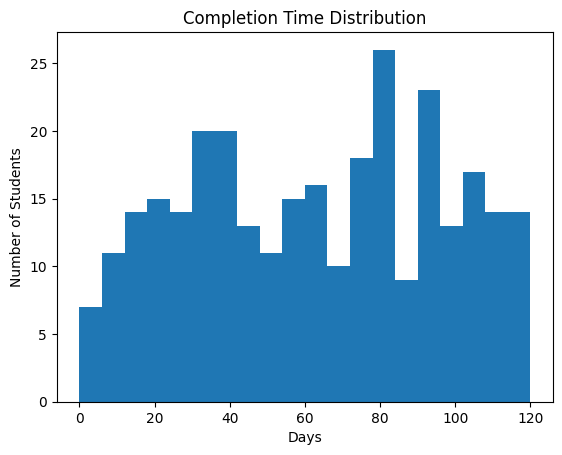

In [10]:
import matplotlib.pyplot as plt

plt.hist(df["completion_days"], bins=20)

plt.title("Completion Time Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Students")

plt.show()

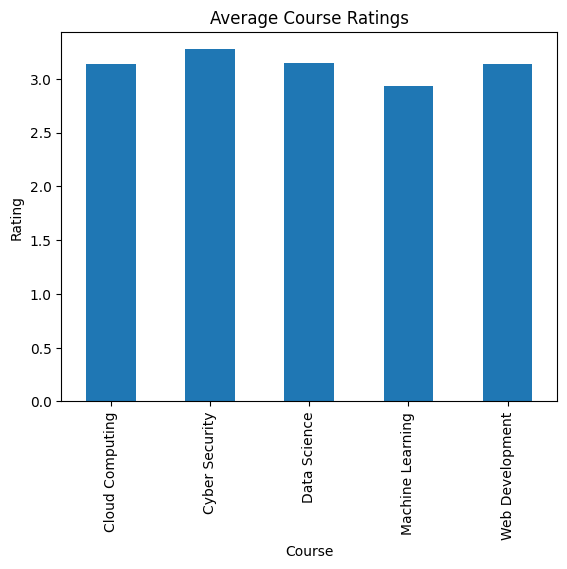

In [11]:
avg_ratings = df.groupby("course_name")["rating"].mean()

avg_ratings.plot(kind="bar")

plt.title("Average Course Ratings")
plt.xlabel("Course")
plt.ylabel("Rating")

plt.show()